In [10]:
import pandas as pd
import sys
import numpy as np
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta_z_scores_numpy, a_for_z_numpy, b_for_z_numpy = load_and_rotate()

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

/mnt/batch/tasks/shared/LS_root/mounts/clusters/cpu10c/code/Users/manhductranvu/reeval-multi/mirt-official/load_params.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m

--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 6])
Original 'a' matrix shape: torch.Size([78712, 6])

--- After Rotation of 'a' ---
Rotated 'a' matrix shape: (78712, 6)

--- After Transformation of 'theta' ---
Transformed theta shape: (183, 6)

--- Final Standardized Z-Scores (from transformed theta) ---
These are the scores you should use for interpretation.
[[ 1.5905465   3.49991235 -2.70676842  0.80146618  0.72562385 -0.62409166]
 [ 1.26710786 -0.50314049  1.10198573 -1.1741239   0.34140497  0.07110775]
 [ 1.86002922  0.60271614  0.90773613  0.07469808 -0.76376825 -1.55688678]
 ...
 [-1.05323766 -0.53844968 -2.76657604  1.42263159  0.66665258  2.97106778]
 [-0.43951293 -0.54343183 -2.60149674  2.23806708  0.32196824  3.12436554]
 [ 0.04734164 -0.47165056 -1.30415358  1.18832103  1.00318341  2.02381296]]


In [11]:
questions = resmat.columns.get_level_values("input.text").to_list()
scenarios = resmat.columns.get_level_values("scenario").to_list()

In [12]:
column_names = ["scenario"] + [f"F{i+1}" for i in range(a_for_z_numpy.shape[1])]
scenarios_reshaped = np.array(scenarios).reshape(-1, 1)
combined_array = np.hstack((scenarios_reshaped, a_for_z_numpy))

df = pd.DataFrame(combined_array, index=questions, columns=column_names)

In [13]:
df.to_csv("../result/item_parameters_rotated_varimax.csv")

In [14]:
unique_scenarios = set()

for col in df.columns:
	if col.startswith("F"):
		print(f"Top 10 questions for {col}:")
		top = df[[col, "scenario"]].sort_values(by=col, ascending=False).head(1000)
		top.to_csv(f"./output/top_questions_{col}.csv")
		print(top)
		print("Unique scenarios and their counts:")
		scenario_counts = top["scenario"].value_counts()
		print(scenario_counts)
		unique_scenarios.update(scenario_counts.index.tolist())
		print()

print(f"Total unique scenarios in top questions across all factors {len(unique_scenarios)}: {unique_scenarios}")
print(f"Total unique scenarios in dataset {len(set(scenarios))}: {set(scenarios)}")
print(f"Missing scenarios: {set(scenarios) - unique_scenarios}")

Top 10 questions for F1:
                                                                        F1  \
There are 3 races. Caucasian, Mongoloid (Asian)...  4.2749610994298294e-05   
The bedroom is south of the kitchen.\nThe bathr...    3.78246659918325e-05   
This is a very bad take. A league that has Blak...      2.9845729359981057   
Awright, mates, scribble doon a scene whaur thi...       2.949274951322425   
Design an algorithm to process the employee rec...      2.9241601119993232   
...                                                                    ...   
Renowned studies in organizational psychology b...      1.6060780135115076   
The percentage of children in Vietnam (age 8) w...      1.6051026410549656   
theese   democrats  wants to  ban guns.\nseems ...      1.6033400882248485   
Prayer meetings should never b allowed in a pub...      1.6026708201820825   
Sheep are afraid of wolves.\nMice are afraid of...      1.6017066892997147   

                                      

# Testing per model family

In [15]:
import pandas as pd

resmat = pd.read_pickle("../data/resmat.pkl")

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta_z_scores_numpy
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

In [16]:
# open_ai = ability_df[ability_df.index.str.contains("anthropic|openai|google", case=False).copy()].copy()
open_ai = ability_df

Top 20 models by sum of abilities:
                                                  F1     F2     F3     F4  \
request.model                                                               
anthropic/claude-3-5-sonnet-20241022          -0.440 -0.543 -2.601  2.238   
anthropic/claude-3-5-sonnet-20240620          -1.053 -0.538 -2.767  1.423   
anthropic/claude-3-opus-20240229              -0.888 -0.053 -1.895  1.547   
anthropic/claude-3-sonnet-20240229            -0.429  0.275 -0.207  0.904   
anthropic/claude-3-haiku-20240307             -0.423 -1.012  0.513  0.802   
openai/text-davinci-003                       -0.895 -1.412 -0.140 -1.358   
meta/llama-3.2-11b-vision-instruct-turbo       0.569 -0.430  2.133  1.637   
google/gemini-1.5-pro-001-safety-block-none    0.047 -0.472 -1.304  1.188   
openai/text-davinci-002                       -0.853 -0.156 -0.470 -1.539   
openai/o1-2024-12-17                          -0.294 -0.308 -0.789  0.681   
google/gemini-1.5-flash-001-safety-block-

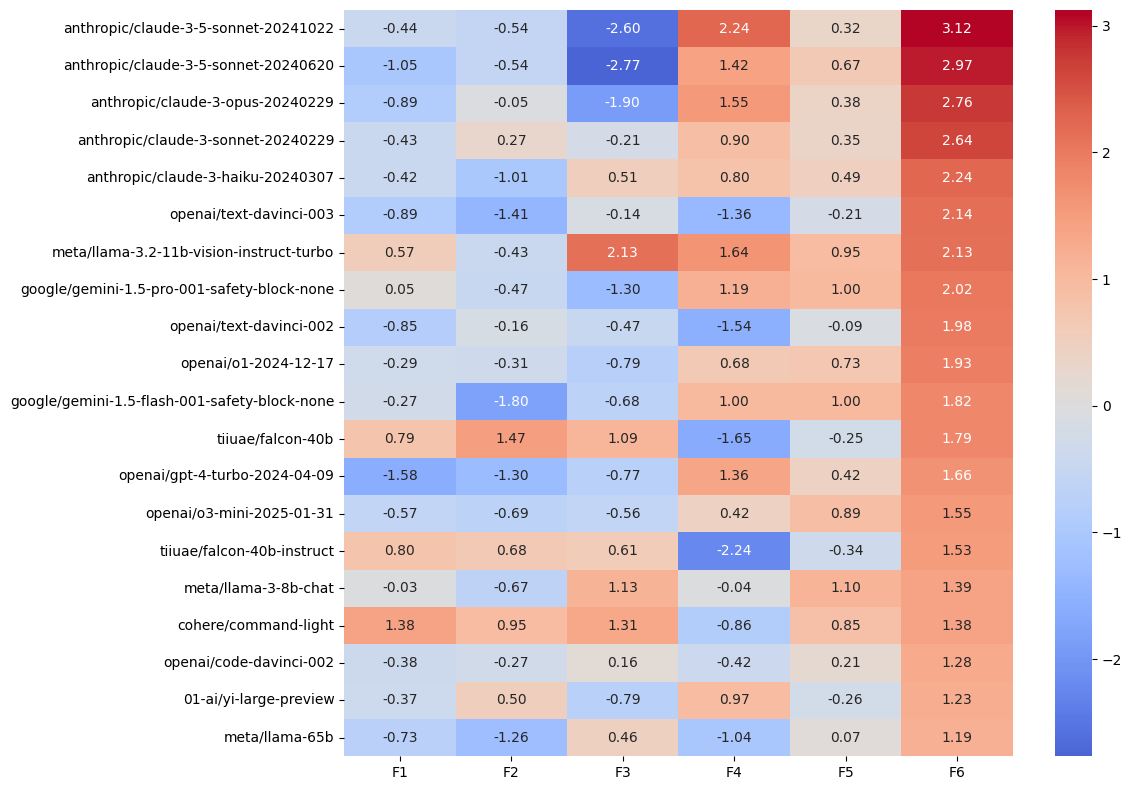

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

tester_df = open_ai
tester_df['aggregated_fs'] = tester_df[['F6']].sum(axis=1)  # Example: sum of F1, F3, F4 as coding-related factors

# Step 3: Calculate sum of abilities and sort
tester_df_sorted = tester_df.sort_values(by='aggregated_fs', ascending=False)
tester_df_sorted.drop(columns=['aggregated_fs'], inplace=True)

# Step 4: Set the number of top models to display
k = 20  # Change this value to display top k models
top_models_df = tester_df_sorted.head(k)

print(f"Top {k} models by sum of abilities:")
print(top_models_df.round(3))

# Step 5: Generate the heatmap using Seaborn
plt.figure(figsize=(12, max(8, k * 0.4)))
sns.heatmap(
	top_models_df,
	annot=True,
	cmap='coolwarm',
	center=0,
	fmt=".2f",
)
plt.ylabel('')
plt.tight_layout()
plt.savefig(f"mirt_theta_heatmap_top{k}.png", dpi=300, bbox_inches='tight')
plt.show()